# Transfer Learning using VGG16/ResNet

## Introduction
This notebook explores the application of transfer learning using popular pre-trained convolutional neural network architectures to address the image classification task on the CIFAR-100 dataset. Leveraging models pre-trained on the large-scale ImageNet dataset, such as ResNet50, VGG16, and MobileNetV2, allows us to benefit from their learned feature extraction capabilities. The goal is to adapt these powerful models to the finer-grained classification challenges presented by CIFAR-100, which consists of 100 distinct classes. This approach significantly reduces the need for training deep models from scratch on a relatively smaller dataset, often leading to improved performance and faster convergence.

**Objective:** To implement transfer learning using pre-trained deep learning models and analyze performance
improvements over custom CNN architectures.

## Project Flow

1.  **Data Loading and Preprocessing**: Load the CIFAR-100 dataset and apply the necessary preprocessing steps tailored for ResNet50 pre-trained model. This involves scaling pixel values and potentially resizing images to match the input requirements of the chosen architectures.

2.  **Model Preparation**:
    *   Load pre-trained model without top classification layers.
    *   Add new custom classification layers suitable for the 100 classes of CIFAR-100.
    *   Freeze the layers of the pre-trained base models to retain the learned features during initial training.
    *   Compile the models with an appropriate optimizer, loss function, and metrics.

3.  **Fine-Tuning and Training**:
    *   Optionally unfreeze a portion of the top layers of the pre-trained models to allow for fine-tuning on the CIFAR-100 data.
    *   Train the modified models on the preprocessed training data, monitoring performance on the validation set.

4.  **Model Evaluation**: Evaluate the performance of each trained model (ResNet50, CNN) on the held-out test dataset using relevant metrics such as accuracy.

5. **Comparison of Results**: Compare the performance of the different models to understand the effectiveness of each architecture for transfer learning on CIFAR-100.

## 1. Data Loading and Preprocessing
Load the CIFAR-100 dataset and prepare it for transfer learning by applying appropriate preprocessing.

In [40]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = cifar100.load_data()


In [9]:
X_train_resnet50 = preprocess_resnet50(X_train)
X_test_resnet50 = preprocess_resnet50(X_test)

In [33]:
y_train_cnn = keras.utils.to_categorical(y_train, num_classes=100)
y_test_cnn = keras.utils.to_categorical(y_test, num_classes=100)

## 2. Model Preparation
Load and modify pre-trained models to fit the CIFAR-100 classification task.

### 2.1 Using ResNet50

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained ResNet50 model without the top layer
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

x = GlobalAveragePooling2D()(base_model_resnet50.output)
x = Dense(1024, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x)

model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=predictions)

model_resnet50.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 2.2 Using CNN

In [41]:
model_cnn = tf.keras.models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu',
                  input_shape=(32, 32, 3), padding='same'),
    layers.Conv2D(32, (3, 3),
                  activation='relu',
                  padding='same'),
    layers.Conv2D(64, (3, 3),
                  activation='relu',
                  padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3),
                  activation='relu',
                  padding='same'),


    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(100, activation='softmax')
])

model_cnn.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['AUC', 'accuracy']
)


## 3. Fine-Tuning and Training
Unfreeze some of the top layers of the pre-trained models and continue training.

In [13]:
epochs = 30

print(len(model_resnet50.layers))


# Fine-tuning ResNet50
for layer in model_resnet50.layers[:-30]:
    layer.trainable = False

for layer in model_resnet50.layers[-30:]:
    layer.trainable = True

history_resnet50    = model_resnet50.fit(X_train_resnet50, y_train, epochs=epochs, validation_data=(X_test_resnet50, y_test))

178
Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.3405 - loss: 2.6551 - val_accuracy: 0.3964 - val_loss: 2.3542
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 14ms/step - accuracy: 0.4617 - loss: 2.0014 - val_accuracy: 0.4394 - val_loss: 2.2102
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.5474 - loss: 1.6231 - val_accuracy: 0.4407 - val_loss: 2.4179
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6377 - loss: 1.2538 - val_accuracy: 0.4481 - val_loss: 2.5030
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7182 - loss: 0.9390 - val_accuracy: 0.4430 - val_loss: 2.7902
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7817 - loss: 0.7099 - val_accuracy: 0.4342 - val_loss: 3.5516
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8171 - loss: 0.5956 - val_accuracy: 0.4381 - val_loss: 3.4125
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.84

In [42]:
print("Training Basic CNN model...")
hist = model_cnn.fit(X_train, y_train_cnn,
                 epochs=30,
                 batch_size=64,
                 verbose=1,
                 validation_data=(X_test, y_test_cnn)
                 )

print("Basic CNN model training finished.")

Training Basic CNN model...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - AUC: 0.7892 - accuracy: 0.1207 - loss: 3.8725 - val_AUC: 0.8356 - val_accuracy: 0.1717 - val_loss: 3.5441
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - AUC: 0.8871 - accuracy: 0.2451 - loss: 3.0744 - val_AUC: 0.8992 - val_accuracy: 0.2631 - val_loss: 2.9275
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - AUC: 0.8960 - accuracy: 0.2721 - loss: 2.9441 - val_AUC: 0.9005 - val_accuracy: 0.2829 - val_loss: 2.8984
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - AUC: 0.8703 - accuracy: 0.2248 - loss: 3.2226 - val_AUC: 0.8998 - val_accuracy: 0.2760 - val_loss: 2.8918
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - AUC: 0.9241 - accuracy: 0.3406 - loss: 2.5810 - val_AUC: 0.9257 - val_accuracy: 0.3639 - val_loss: 2.5177
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - AUC: 0.9049 - accuracy: 0.3118 - loss: 2.7818 - val_AUC: 0.8020 - val_accuracy: 0.1488 - val_loss: 3.9327
Epoch

## 4. Model Evaluation
Evaluate each model on the test dataset to compare their performance.

In [44]:
acc_resnet50    = model_resnet50.evaluate(X_test_resnet50, y_test)[1]
acc_cnn       = model_cnn.evaluate(X_test, y_test_cnn)[1]

print(f'ResNet50 Accuracy: {acc_resnet50:.2f}')
print(f'CNN Accuracy: {acc_cnn:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4454 - loss: 7.4808
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.8023 - accuracy: 0.3542 - loss: 4.6709
ResNet50 Accuracy: 0.45
CNN Accuracy: 0.80


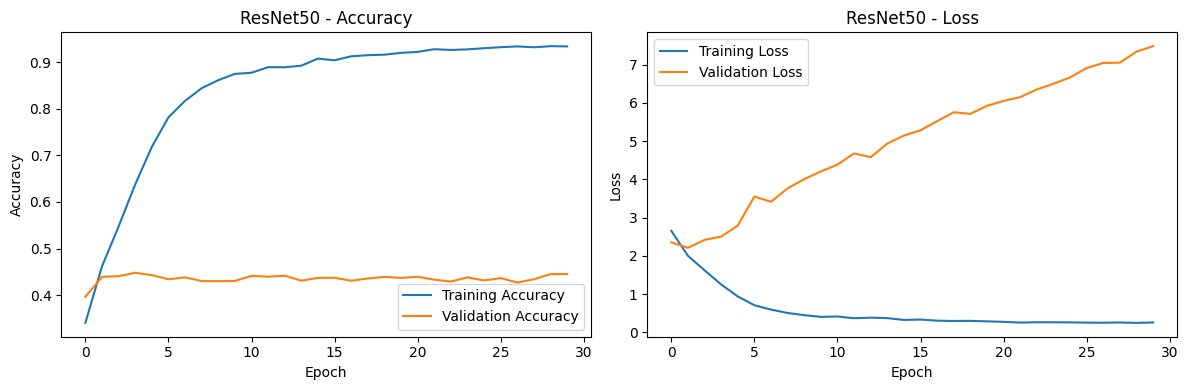

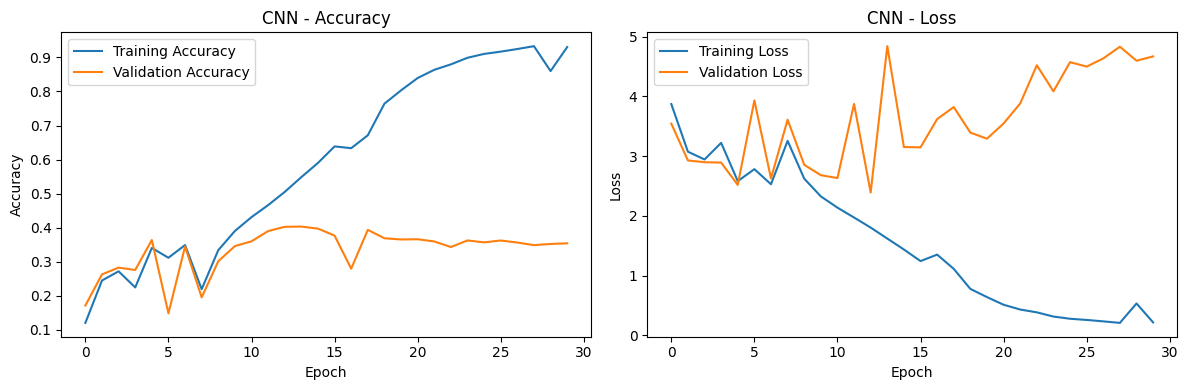

In [45]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet50, 'ResNet50')
plot_history(hist, 'CNN')

## Project Summary

*   **Data Loading and Preprocessing**: Loaded the CIFAR-100 dataset and preprocessed images using model-specific functions.
*   **Model Adaptation**: Loaded pre-trained ResNet50 added new classification layers for 100 classes, and initially froze base model layers.
*   **Model Compilation**: Compiled each modified model with the 'adam' optimizer, 'sparse\_categorical\_crossentropy' loss, and 'accuracy' metric.
*   **Fine-Tuning (Example)**: Demonstrated fine-tuning by unfreezing top layers of the ResNet50 model and training it for 30 epochs.
*   **Model Evaluation**: Evaluated the trained models on the test set to determine and compare their classification accuracies.

## CONCLUSION

The aim of this assignment was to compare the results of a basic CNN to that of a transfer learning RESNET 50 model. When the accuracy of both were compared the basic CNN model shows a lot higher accurcy (approximately 50% greater) then that of RESNET. This could have varied reasons. When evaluating the model fitting epochs we come to the conclusion that the RESNET 50 model was overfitted which could be observed via the high accuracy of training (~90%) compared to that of the validation accuracy (approximately 45%) which is directly half of the other. The reason behind this could be a small dataset or that we should have finetuned more layers.

Compared to that the CNN model performed exceptionally in both training as well as validation phase with a high accuracy in both. When compared the CNN model should be selected for the classification task.

When their training time is compared the RESNET model (14 m/s) being finetuned takes longer time compared to CNN (11 m/s) as well. While the accuracy of RESNET over validation does increase over time the loss also increases exponentially. Comparatively the accuracy of CNN increases while its loss decreases after a sharp increase